In [29]:
import pandas as pd

# 1) Path to your Excel file
file_path = r"D:\VScode\Inso_LGMR\icecore_data\Five_icecore_data.xlsx"

# 2) Read in the workbook
xls = pd.ExcelFile(file_path)

# 3) For each sheet, read it and assign to df_<sheetname>
for sheet in xls.sheet_names:
    # Make a valid Python identifier out of the sheet name
    safe_name = sheet.strip().replace(" ", "_").replace("-", "_")
    df_name = f"df_{safe_name}"
    
    # Load the sheet into a DataFrame
    df = pd.read_excel(xls, sheet_name=sheet)
    
    # Assign it into globals() so you can refer to df_<sheet>
    globals()[df_name] = df
    
    # (Optional) Print confirmation
    print(f"{df_name} → shape {df.shape}")


df_wdc → shape (6373, 2)
df_edml → shape (3350, 2)
df_edc → shape (1648, 2)
df_Fuji → shape (1364, 2)
df_Talos → shape (1671, 2)
df_Five_core → shape (6101, 2)


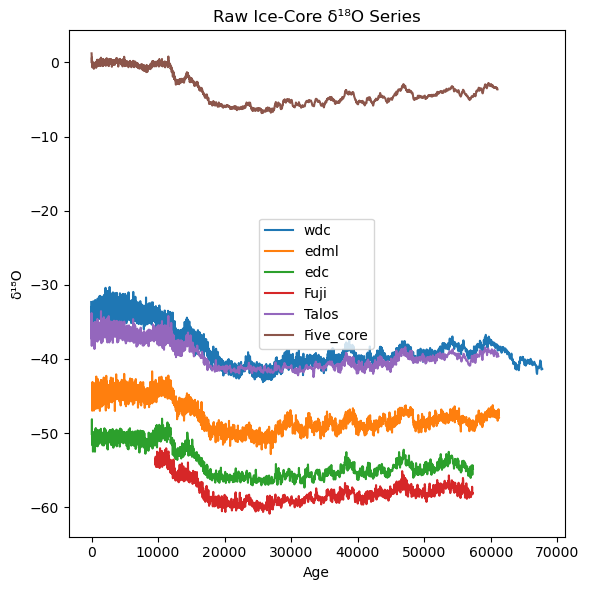

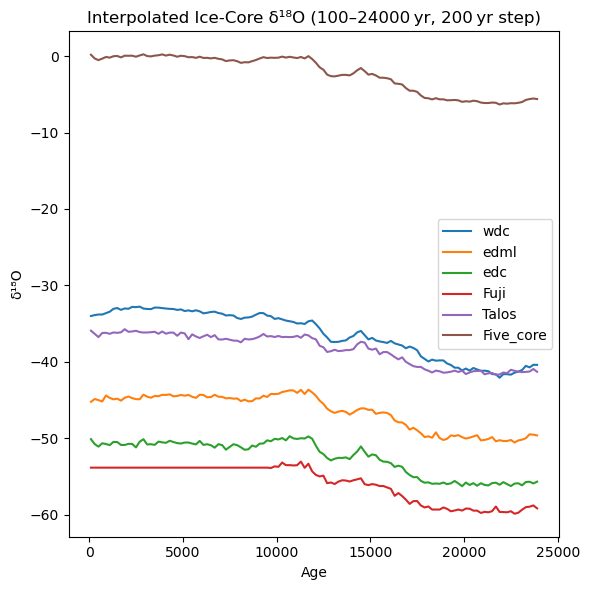

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0) Path to your Excel file
file_path = r"D:\VScode\Inso_LGMR\icecore_data\Five_icecore_data.xlsx"

# 1) Read all sheets into a dict
xls = pd.ExcelFile(file_path)
dfs = {
    sheet: pd.read_excel(xls, sheet_name=sheet)
    for sheet in xls.sheet_names
}

# 2) Plot all raw series
plt.figure(figsize=(6, 6))
for sheet, df in dfs.items():
    plt.plot(df['age'], df['d18O'], label=sheet)
plt.xlabel('Age')
plt.ylabel('δ¹⁸O')
plt.title('Raw Ice‑Core δ¹⁸O Series')
plt.legend()
plt.tight_layout()
plt.show()


# resample each series from their original age start and end with a step of 1
dfs_interp = {}
for sheet, df in dfs.items():
    new_age = np.arange(df['age'].min(), df['age'].max() + 1, 1)  # 1 ≤ age < max_age, step 1
    df_sorted = df.sort_values('age')
    interp_vals = np.interp(new_age,
                            df_sorted['age'],
                            df_sorted['d18O'])
    dfs_interp[sheet] = pd.DataFrame({
        'age': new_age,
        'd18O': interp_vals
    })
    dfs_interp[sheet]['d18O'] = dfs_interp[sheet] ['d18O'].rolling(window=200, min_periods=1).mean()

dfs=dfs_interp.copy()


# 3) Create new age grid and interpolate each series onto it
new_age = np.arange(100, 24000, 200)  # 100 ≤ age < 24000, step 200
dfs_interp = {}
for sheet, df in dfs.items():
    df_sorted = df.sort_values('age')
    interp_vals = np.interp(new_age,
                            df_sorted['age'],
                            df_sorted['d18O'])
    dfs_interp[sheet] = pd.DataFrame({
        'age': new_age,
        'd18O': interp_vals
    })
    

# 4) Plot all interpolated series
plt.figure(figsize=(6, 6))
for sheet, dfi in dfs_interp.items():
    plt.plot(dfi['age'], dfi['d18O'], label=sheet)
plt.xlabel('Age')
plt.ylabel('δ¹⁸O')
plt.title('Interpolated Ice‑Core δ¹⁸O (100–24000 yr, 200 yr step)')
plt.legend()
plt.tight_layout()
plt.show()


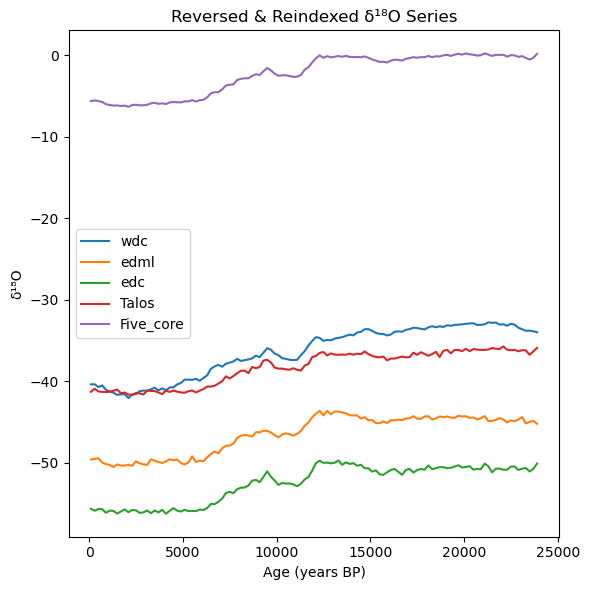

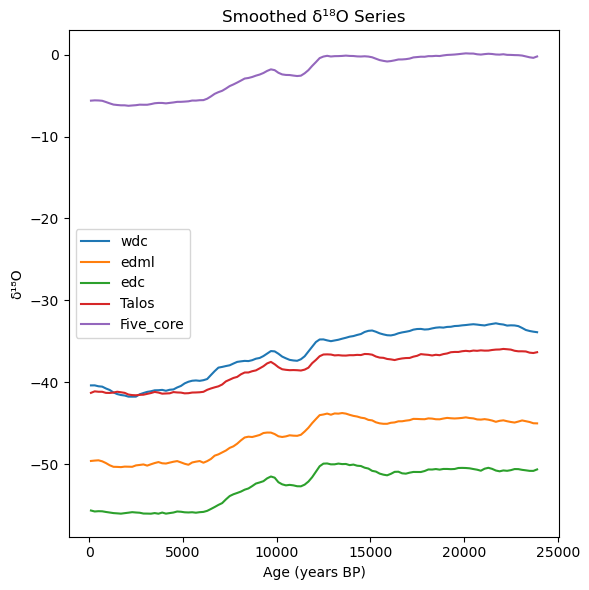

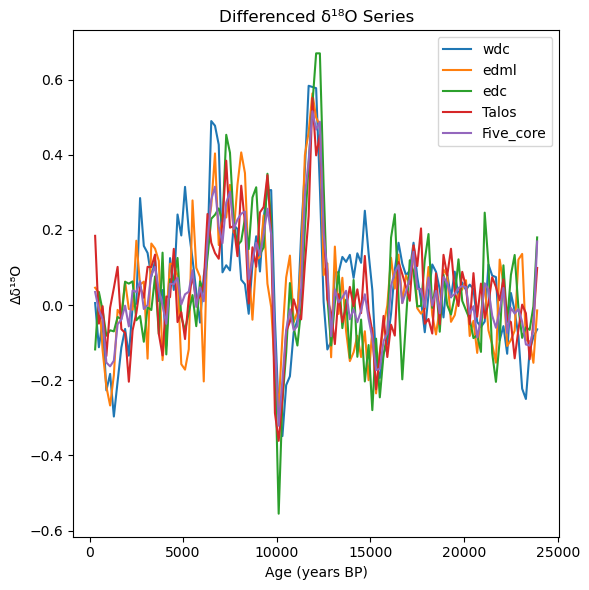

Saved: D:\VScode\Inso_LGMR\icecore_data\wdc_d18O_diff.csv
Saved: D:\VScode\Inso_LGMR\icecore_data\edml_d18O_diff.csv
Saved: D:\VScode\Inso_LGMR\icecore_data\edc_d18O_diff.csv
Saved: D:\VScode\Inso_LGMR\icecore_data\Talos_d18O_diff.csv
Saved: D:\VScode\Inso_LGMR\icecore_data\Five_core_d18O_diff.csv


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. Remove the 'Fuji' series if it exists
dfs_interp.pop('Fuji', None)

# 2. Reverse each series in time, shift age so that 0→24000, then reindex
for name, df in dfs_interp.items():
    # reverse the rows
    df_rev = df.iloc[::-1].copy()
    # shift age: age_rev = -age_orig + 24000
    df_rev['age'] = -df_rev['age'] + 24000
    # reset index so it's 0…N-1
    df_rev.reset_index(drop=True, inplace=True)
    dfs_interp[name] = df_rev

# 2b. Plot all reversed & reindexed series
plt.figure(figsize=(6, 6))
for name, df in dfs_interp.items():
    plt.plot(df['age'], df['d18O'], label=name)
plt.xlabel('Age (years BP)')
plt.ylabel('δ¹⁸O')
plt.title('Reversed & Reindexed δ¹⁸O Series')
plt.legend()
plt.tight_layout()
plt.show()


# smooth the column d18O using a rolling mean with a window of 5

for name, df in dfs_interp.items():
    df['d18O'] = df['d18O'].rolling(window=3, min_periods=1).mean()
    # drop any NaNs that may have been introduced by the rolling mean
    df = df.dropna(subset=['d18O']).reset_index(drop=True)
    dfs_interp[name] = df

plt.figure(figsize=(6, 6))
for name, df in dfs_interp.items():
    plt.plot(df['age'], df['d18O'], label=name)
plt.xlabel('Age (years BP)')
plt.ylabel('δ¹⁸O')
plt.title('Smoothed δ¹⁸O Series')
plt.legend()
plt.tight_layout()
plt.show()


# 3. Compute the first difference of d18O, drop the original column and any NaNs
for name, df in dfs_interp.items():
    df['d18O_diff'] = df['d18O'].diff()
    df = df.drop(columns=['d18O'])
    df = df.dropna(subset=['d18O_diff']).reset_index(drop=True)
    dfs_interp[name] = df

# 3b. Plot the differenced series
plt.figure(figsize=(6, 6))
for name, df in dfs_interp.items():
    plt.plot(df['age'], df['d18O_diff'], label=name)
plt.xlabel('Age (years BP)')
plt.ylabel('Δδ¹⁸O')
plt.title('Differenced δ¹⁸O Series')
plt.legend()
plt.tight_layout()
plt.show()



import os

# Directory where to save the CSVs
out_dir = r"D:\VScode\Inso_LGMR\icecore_data"

for name, df in dfs_interp.items():
    # Construct a safe filename
    safe_name = name.strip().replace(" ", "_")
    filename = f"{safe_name}_d18O_diff.csv"
    filepath = os.path.join(out_dir, filename)
    
    # Save to CSV
    df.to_csv(filepath, index=False)
    
    print(f"Saved: {filepath}")


In [22]:
dfs_interp['edc']

,age,d18O_diff
0,300,0.434012
1,500,-1.186997
2,700,1.415554
3,900,-1.046280
4,1100,0.311280
...,...,...
114,23100,-0.209824
115,23300,0.322716
116,23500,0.686677
117,23700,-0.411251


In [24]:
df_pre

,age,pre
0,300.0,0.017182
1,500.0,0.017535
2,700.0,0.017836
3,900.0,0.018083
4,1100.0,0.018273
...,...,...
114,23100.0,0.017104
115,23300.0,0.017029
116,23500.0,0.016891
117,23700.0,0.016690


In [65]:
import pandas as pd
import importlib
from toolbox import significant_test as st

# Reload in case you’ve tweaked the function
importlib.reload(st)

# 1) Load your precession data once
df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")

# 2) For each differenced ice‑core series in dfs_interp…
results = {}
for core_name, df_diff in dfs_interp.items():
    # build the merged DataFrame
    df_merged = pd.DataFrame({
        'age':       df_diff['age'].values,
        'diff_temp': df_diff['d18O_diff'].values,
        'pre':       df_pre['pre'].values
    })

    # 3) Run unidirectional CCM test: diff_temp → pre
    ccm_out, ran_ccm_list, test_result = st.ccm_significance_test_v2_df(
        df_input   = df_merged,
        E          = 5,
        tau        = -4,
        Tp         = 0,
        n_ran      = 100,
        libSizes   = "10 20 30 40 50 60 70 80",
        random     = True,
        sample     = 20,
        showPlot   = False   # turn off individual plots
    )

    # store and print
    results[core_name] = test_result
    print(f"{core_name}: unidirectional causality pre → diff_temp? {test_result}")

# 4) Optionally, collect and display in a DataFrame
df_results = pd.DataFrame.from_dict(
    results, orient='index', columns=['Temp_xmap_pre', 'pre_xmap_Temp']
)
print("\nSummary of causality tests:")
print(df_results)


wdc: unidirectional causality pre → diff_temp? (False, False)
edml: unidirectional causality pre → diff_temp? (False, False)
edc: unidirectional causality pre → diff_temp? (True, False)
Talos: unidirectional causality pre → diff_temp? (True, False)
Five_core: unidirectional causality pre → diff_temp? (True, False)

Summary of causality tests:
           Temp_xmap_pre  pre_xmap_Temp
wdc                False          False
edml               False          False
edc                 True          False
Talos               True          False
Five_core           True          False


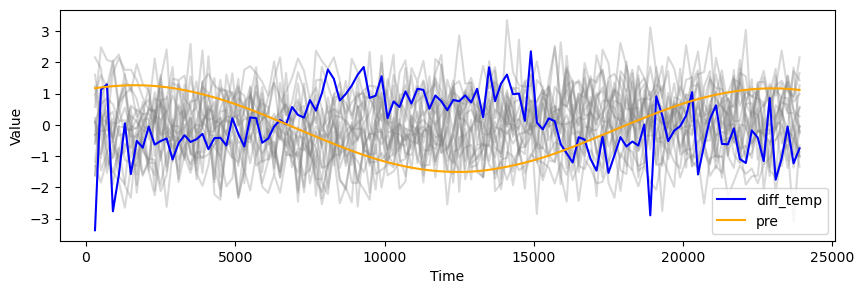

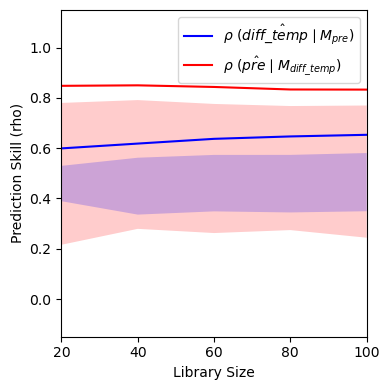

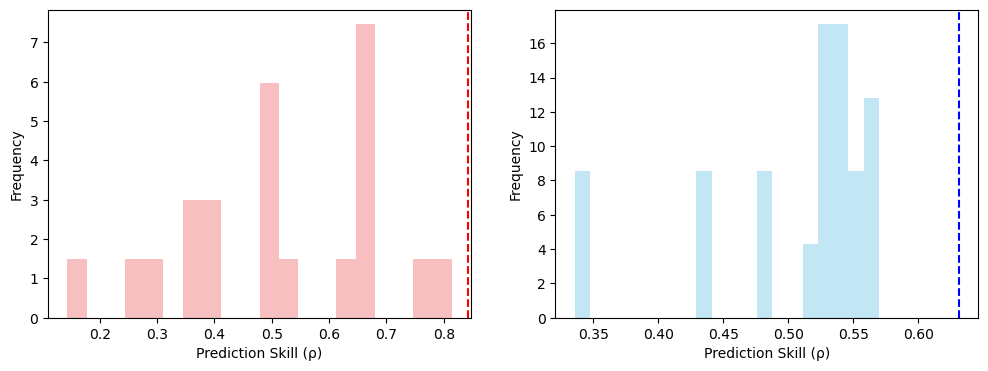

(True, True)


In [35]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)


df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")

df_merged = pd.DataFrame({
    'age':       dfs_interp['edml']['age'].values,
    'diff_temp': dfs_interp['edml']['d18O_diff'].values,
    'pre':       df_pre['pre'].values
})


ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v3_df(
    df_input      = df_merged,
    E         = 5,
    tau       = -3,
    Tp =0,
    n_ran     = 20,
    libSizes  = "20 40 60 80 100",
    random=True,
    sample    = 20,
    showPlot  = True
)

# print test_result
print(test_result)

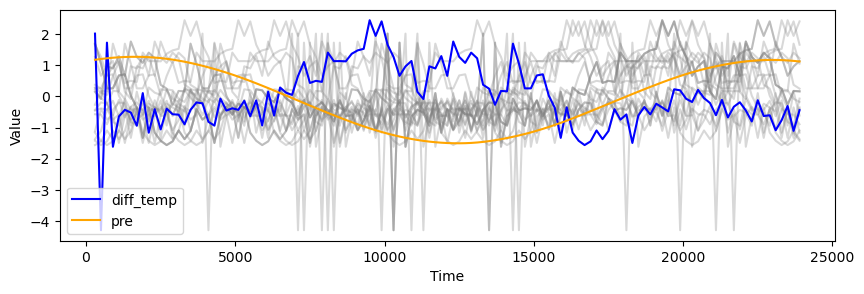

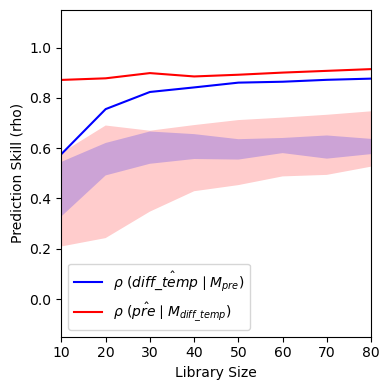

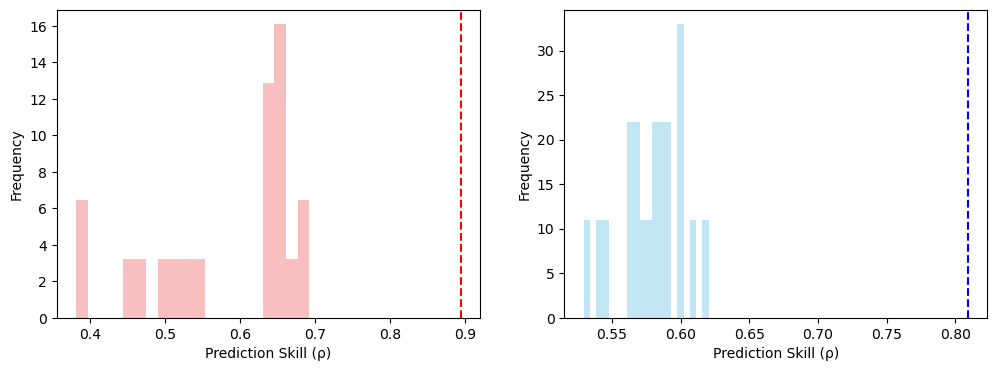

(True, True)


In [ ]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)


df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")

df_merged = pd.DataFrame({
    'age':       dfs_interp['edc']['age'].values,
    'diff_temp': dfs_interp['edc']['d18O_diff'].values,
    'pre':       df_pre['pre'].values
})


ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2_df(
    df_input      = df_merged,
    E         = 5,
    tau       = -3,
    Tp =0,
    n_ran     = 20,
    libSizes  = "20 40 60 80 100",
    random=True,
    sample    = 20,
    showPlot  = True
)

# print test_result
print(test_result)

In [24]:
import pandas as pd
import importlib
from toolbox import significant_test as st

# Reload in case you’ve tweaked the function
importlib.reload(st)

# 1) Load your precession data once
df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")

# 2) For each differenced ice‑core series in dfs_interp…
results = {}
for core_name, df_diff in dfs_interp.items():
    # build the merged DataFrame
    df_merged = pd.DataFrame({
        'age':       df_diff['age'].values,
        'diff_temp': df_diff['d18O_diff'].values,
        'pre':       df_pre['pre'].values
    })

    # 3) Run unidirectional CCM test: diff_temp → pre
    ccm_out, ran_ccm_list, test_result = st.ccm_significance_test_v3_df(
        df_input   = df_merged,
        E          = 5,
        tau        = -3,
        Tp         = 0,
        n_ran      = 100,
        libSizes   = "10 20 30 40 50 60 70 80",
        random     = True,
        sample     = 20,
        showPlot   = False   # turn off individual plots
    )

    # store and print
    results[core_name] = test_result
    print(f"{core_name}: unidirectional causality pre → diff_temp? {test_result}")

# 4) Optionally, collect and display in a DataFrame
df_results = pd.DataFrame.from_dict(
    results, orient='index', columns=['Temp_xmap_pre', 'pre_xmap_Temp']
)
print("\nSummary of causality tests:")
print(df_results)


wdc: unidirectional causality pre → diff_temp? (False, True)
edml: unidirectional causality pre → diff_temp? (True, False)
edc: unidirectional causality pre → diff_temp? (True, True)
Talos: unidirectional causality pre → diff_temp? (False, False)
Five_core: unidirectional causality pre → diff_temp? (False, False)

Summary of causality tests:
           Temp_xmap_pre  pre_xmap_Temp
wdc                False           True
edml                True          False
edc                 True           True
Talos              False          False
Five_core          False          False


# Full length data

In [7]:
import pandas as pd

# 1) Path to your Excel file
file_path = r"D:\VScode\Inso_LGMR\icecore_data\Five_icecore_data.xlsx"

# 2) Read in the workbook
xls = pd.ExcelFile(file_path)

# 3) For each sheet, read it and assign to df_<sheetname>
for sheet in xls.sheet_names:
    # Make a valid Python identifier out of the sheet name
    safe_name = sheet.strip().replace(" ", "_").replace("-", "_")
    df_name = f"df_{safe_name}"
    
    # Load the sheet into a DataFrame
    df = pd.read_excel(xls, sheet_name=sheet)
    
    # Assign it into globals() so you can refer to df_<sheet>
    globals()[df_name] = df
    
    # (Optional) Print confirmation
    print(f"{df_name} → shape {df.shape}")


df_wdc → shape (6373, 2)
df_edml → shape (3350, 2)
df_edc → shape (1648, 2)
df_Fuji → shape (1364, 2)
df_Talos → shape (1671, 2)
df_Five_core → shape (6101, 2)


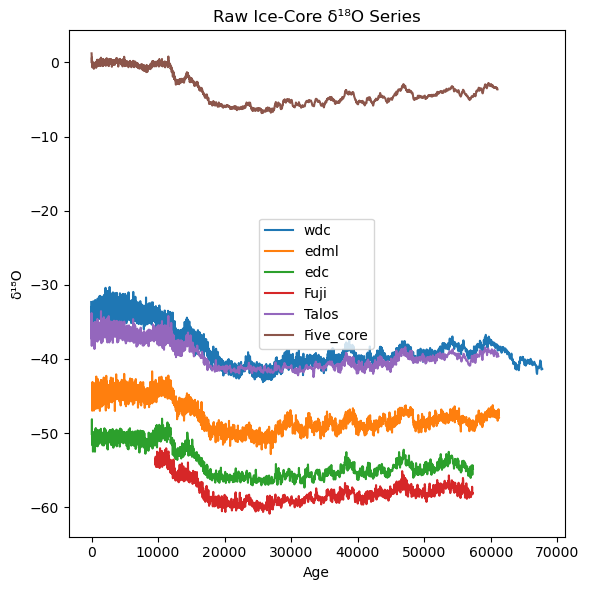

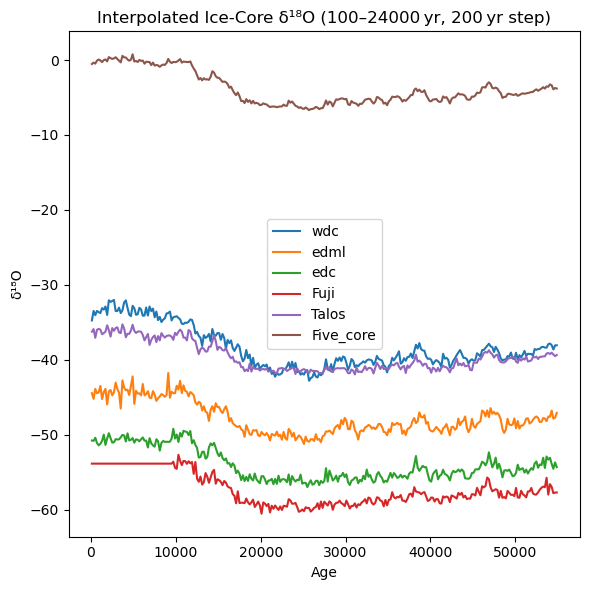

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0) Path to your Excel file
file_path = r"D:\VScode\Inso_LGMR\icecore_data\Five_icecore_data.xlsx"

# 1) Read all sheets into a dict
xls = pd.ExcelFile(file_path)
dfs = {
    sheet: pd.read_excel(xls, sheet_name=sheet)
    for sheet in xls.sheet_names
}

# 2) Plot all raw series
plt.figure(figsize=(6, 6))
for sheet, df in dfs.items():
    plt.plot(df['age'], df['d18O'], label=sheet)
plt.xlabel('Age')
plt.ylabel('δ¹⁸O')
plt.title('Raw Ice‑Core δ¹⁸O Series')
plt.legend()
plt.tight_layout()
plt.show()

# 3) Create new age grid and interpolate each series onto it
new_age = np.arange(100, 55000, 200)  # 100 ≤ age < 24000, step 200
dfs_interp = {}
for sheet, df in dfs.items():
    df_sorted = df.sort_values('age')
    interp_vals = np.interp(new_age,
                            df_sorted['age'],
                            df_sorted['d18O'])
    dfs_interp[sheet] = pd.DataFrame({
        'age': new_age,
        'd18O': interp_vals
    })

# 4) Plot all interpolated series
plt.figure(figsize=(6, 6))
for sheet, dfi in dfs_interp.items():
    plt.plot(dfi['age'], dfi['d18O'], label=sheet)
plt.xlabel('Age')
plt.ylabel('δ¹⁸O')
plt.title('Interpolated Ice‑Core δ¹⁸O (100–24000 yr, 200 yr step)')
plt.legend()
plt.tight_layout()
plt.show()

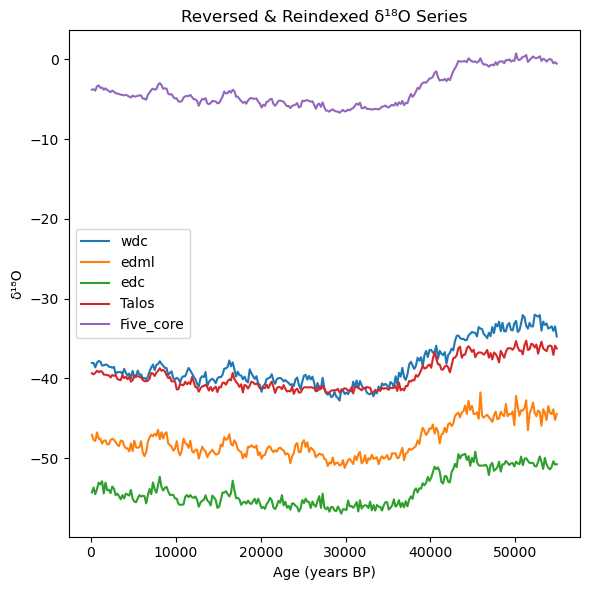

       age       d18O
0      100 -38.053773
1      300 -38.061083
2      500 -38.246386
3      700 -38.192964
4      900 -38.118502
..     ...        ...
270  54100 -32.913394
271  54300 -33.059355
272  54500 -33.249362
273  54700 -33.369362
274  54900 -33.638133

[275 rows x 2 columns]
       age       d18O
0      100 -47.073667
1      300 -47.391079
2      500 -47.539117
3      700 -47.346621
4      900 -47.392806
..     ...        ...
270  54100 -44.443813
271  54300 -44.457122
272  54500 -44.370334
273  54700 -44.488835
274  54900 -44.512017

[275 rows x 2 columns]
       age       d18O
0      100 -54.304250
1      300 -53.991356
2      500 -54.170790
3      700 -54.096762
4      900 -53.889648
..     ...        ...
270  54100 -50.745016
271  54300 -50.753575
272  54500 -50.689270
273  54700 -50.724472
274  54900 -50.821795

[275 rows x 2 columns]
       age       d18O
0      100 -39.353704
1      300 -39.422976
2      500 -39.376894
3      700 -39.292860
4      900 -39.279243
..  

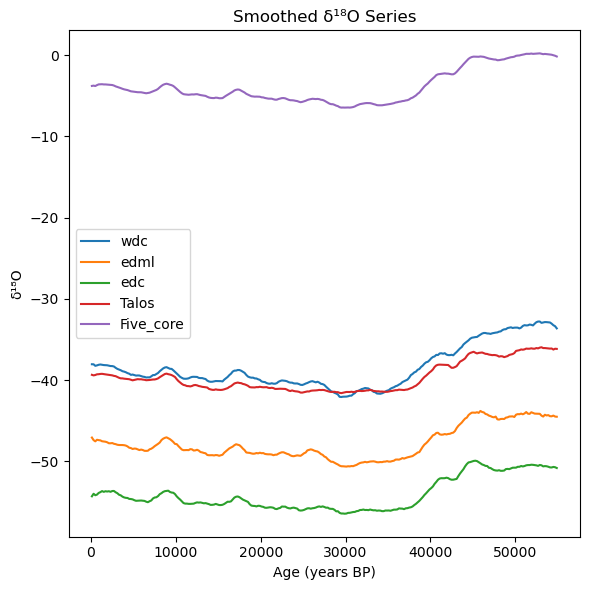

       age  d18O_diff
0      300  -0.007311
1      500  -0.185303
2      700   0.053422
3      900   0.074463
4     1100   0.035371
..     ...        ...
269  54100  -0.014984
270  54300  -0.145961
271  54500  -0.190007
272  54700  -0.120000
273  54900  -0.268771

[274 rows x 2 columns]
       age  d18O_diff
0      300  -0.317412
1      500  -0.148038
2      700   0.192496
3      900  -0.046185
4     1100  -0.027895
..     ...        ...
269  54100  -0.130605
270  54300  -0.013308
271  54500   0.086788
272  54700  -0.118501
273  54900  -0.023182

[274 rows x 2 columns]
       age  d18O_diff
0      300   0.312894
1      500  -0.179434
2      700   0.074028
3      900   0.207114
4     1100   0.098664
..     ...        ...
269  54100  -0.082002
270  54300  -0.008559
271  54500   0.064306
272  54700  -0.035202
273  54900  -0.097323

[274 rows x 2 columns]
       age  d18O_diff
0      300  -0.069272
1      500   0.046082
2      700   0.084033
3      900   0.013617
4     1100   0.033202
..  

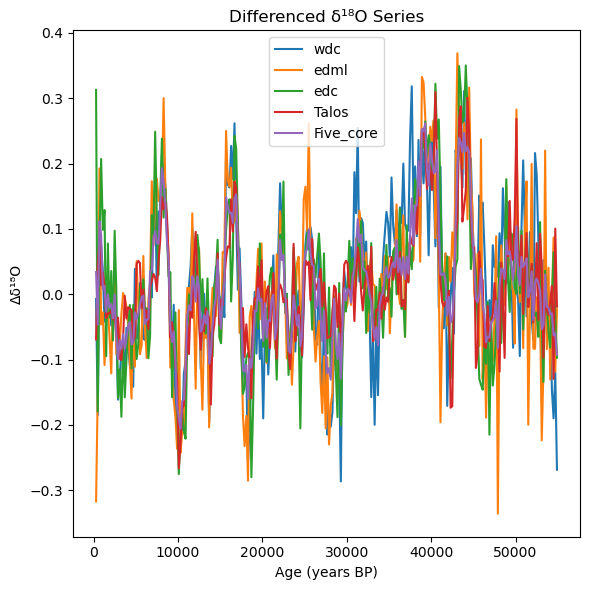

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. Remove the 'Fuji' series if it exists
dfs_interp.pop('Fuji', None)

# 2. Reverse each series in time, shift age so that 0→24000, then reindex
for name, df in dfs_interp.items():
    # reverse the rows
    df_rev = df.iloc[::-1].copy()
    # shift age: age_rev = -age_orig + 24000
    df_rev['age'] = -df_rev['age'] + 55000
    # reset index so it's 0…N-1
    df_rev.reset_index(drop=True, inplace=True)
    dfs_interp[name] = df_rev

# 2b. Plot all reversed & reindexed series
plt.figure(figsize=(6, 6))
for name, df in dfs_interp.items():
    plt.plot(df['age'], df['d18O'], label=name)
plt.xlabel('Age (years BP)')
plt.ylabel('δ¹⁸O')
plt.title('Reversed & Reindexed δ¹⁸O Series')
plt.legend()
plt.tight_layout()
plt.show()


# smooth the column d18O using a rolling mean with a window of 5

for name, df in dfs_interp.items():
    df['d18O'] = df['d18O'].rolling(window=10, min_periods=1).mean()
    # drop any NaNs that may have been introduced by the rolling mean
    df = df.dropna(subset=['d18O']).reset_index(drop=True)
    dfs_interp[name] = df
    print(df)

plt.figure(figsize=(6, 6))
for name, df in dfs_interp.items():
    plt.plot(df['age'], df['d18O'], label=name)
plt.xlabel('Age (years BP)')
plt.ylabel('δ¹⁸O')
plt.title('Smoothed δ¹⁸O Series')
plt.legend()
plt.tight_layout()
plt.show()


# 3. Compute the first difference of d18O, drop the original column and any NaNs
for name, df in dfs_interp.items():
    df['d18O_diff'] = df['d18O'].diff()
    df = df.drop(columns=['d18O'])
    df = df.dropna(subset=['d18O_diff']).reset_index(drop=True)
    dfs_interp[name] = df
    print(df)

# 3b. Plot the differenced series
plt.figure(figsize=(6, 6))
for name, df in dfs_interp.items():
    plt.plot(df['age'], df['d18O_diff'], label=name)
plt.xlabel('Age (years BP)')
plt.ylabel('Δδ¹⁸O')
plt.title('Differenced δ¹⁸O Series')
plt.legend()
plt.tight_layout()
plt.show()



import os

# # Directory where to save the CSVs
# out_dir = r"D:\VScode\Inso_LGMR\icecore_data"

# for name, df in dfs_interp.items():
#     # Construct a safe filename
#     safe_name = name.strip().replace(" ", "_")
#     filename = f"{safe_name}_d18O_diff.csv"
#     filepath = os.path.join(out_dir, filename)
    
#     # Save to CSV
#     df.to_csv(filepath, index=False)
    
#     print(f"Saved: {filepath}")


         age       pre
0      500.0 -0.003824
1      700.0 -0.003029
2      900.0 -0.002239
3     1100.0 -0.001456
4     1300.0 -0.000685
..       ...       ...
269  54100.0  0.017104
270  54300.0  0.017029
271  54500.0  0.016891
272  54700.0  0.016690
273  54900.0  0.016431

[274 rows x 2 columns]


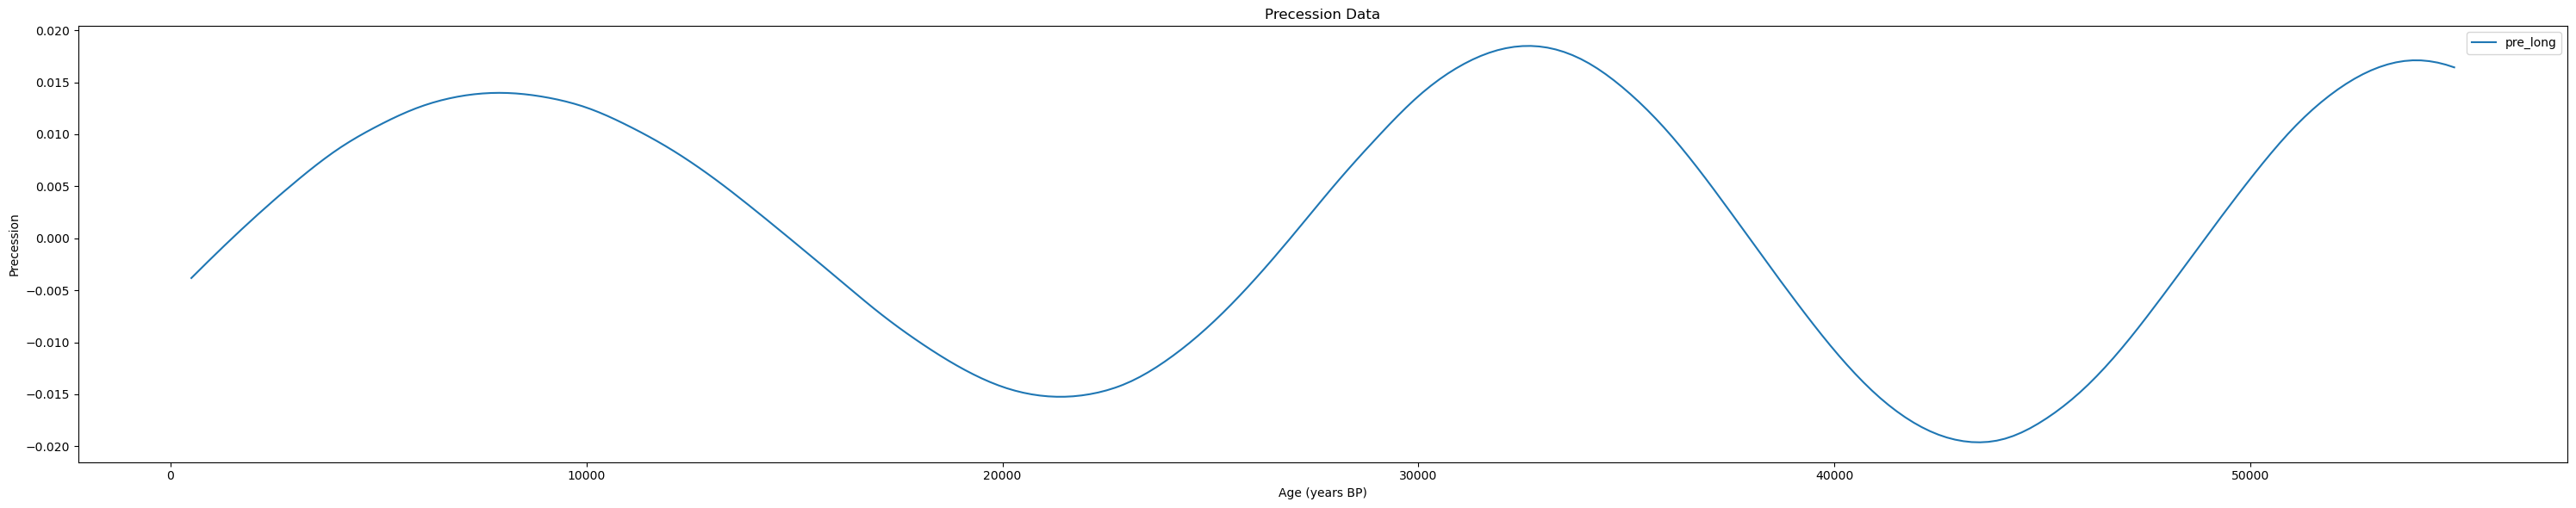

In [25]:
import pandas as pd

# Read the file into a DataFrame
df_pre_long = pd.read_csv(
    r"D:\VScode\Inso_LGMR\inso_data\pre_800.txt", 
    sep='\s+',       # '\s+' means "split on any whitespace"
    header=None,     # or specify a row number if there's a header
    engine='python'
)


df_pre_long.iloc[:, 0] = df_pre_long.iloc[:, 0].abs() * 1000


# Rename the columns
df_pre_long.columns = ['age', 'pre']



# crop the data for age>=100 <=23900
df_pre_long = df_pre_long[(df_pre_long['age'] >= 100) & (df_pre_long['age'] <= 55000)]


# remove rows that can be divided by 200
df_pre_long = df_pre_long[df_pre_long['age'] % 200 != 0]

# the age column * -1 +24000
df_pre_long['age'] = df_pre_long['age'] * -1 + 55000

# drop the first two rows 
df_pre_long = df_pre_long[2:]

# reset the index
df_pre_long.reset_index(drop=True, inplace=True)
print(df_pre_long)

# df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")
# df_pre_long =pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre_800.csv")

# plot the precession data
plt.figure(figsize=(30, 6))
# plt.plot(df_pre['age'], df_pre['pre'], label='pre')
plt.plot(df_pre_long['age'], df_pre_long['pre'], label='pre_long')
plt.xlabel('Age (years BP)')
plt.ylabel('Precession')
plt.title('Precession Data')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
df_pre_long

,age,pre
0,100.0,-0.005414
1,300.0,-0.004620
2,500.0,-0.003824
3,700.0,-0.003029
4,900.0,-0.002239
...,...,...
271,54100.0,0.017104
272,54300.0,0.017029
273,54500.0,0.016891
274,54700.0,0.016690


In [28]:
import pandas as pd
import importlib
from toolbox import significant_test as st

# Reload in case you’ve tweaked the function
importlib.reload(st)

# 1) Load your precession data once
# df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")
df_pre=df_pre_long

# 2) For each differenced ice‑core series in dfs_interp…
results = {}
for core_name, df_diff in dfs_interp.items():
    # build the merged DataFrame
    df_merged = pd.DataFrame({
        'age':       df_diff['age'].values,
        'diff_temp': df_diff['d18O_diff'].values,
        'pre':       df_pre['pre'].values
    })

    # # crop the df for age from 30000 to 55000
    # df_merged = df_merged[(df_merged['age'] >= 30000) & (df_merged['age'] <= 55000)]

    # 3) Run unidirectional CCM test: diff_temp → pre
    ccm_out, ran_ccm_list, test_result = st.ccm_significance_test_v2_df(
        df_input   = df_merged,
        E          = 5,
        tau        = -3,
        Tp         = 0,
        n_ran      = 100,
        libSizes   = "40 80 120 160 200 240",
        random     = True,
        sample     = 20,
        showPlot   = False   # turn off individual plots
    )

    # store and print
    results[core_name] = test_result
    print(f"{core_name}: unidirectional causality pre → diff_temp? {test_result}")

# 4) Optionally, collect and display in a DataFrame
df_results = pd.DataFrame.from_dict(
    results, orient='index', columns=['Temp_xmap_pre', 'pre_xmap_Temp']
)
print("\nSummary of causality tests:")
print(df_results)


wdc: unidirectional causality pre → diff_temp? (False, False)
edml: unidirectional causality pre → diff_temp? (False, False)
edc: unidirectional causality pre → diff_temp? (False, False)
Talos: unidirectional causality pre → diff_temp? (False, False)
Five_core: unidirectional causality pre → diff_temp? (True, False)

Summary of causality tests:
           Temp_xmap_pre  pre_xmap_Temp
wdc                False          False
edml               False          False
edc                False          False
Talos              False          False
Five_core           True          False
